### Predicting the Cost of a Person's Health Insurance
The major insurance company 4Geeks Insurance S.L. wants to calculate, based on its clients' physiological data, the premium (cost) each of them will have to pay. To do this, it has assembled a team of doctors and, using data from other companies and a specific study, has compiled a dataset to train a predictive model.

In [20]:
#Import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle

In [2]:
# Access dataset
df = pd.read_csv("/workspaces/crerov-intro-machine-learning/data/raw/medical_insurance_cost.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#### Variables description
age. Age of primary beneficiary (numeric)

sex. Gender of primary beneficiary (categorical)

bmi. Body mass index (numeric)

children. Number of children/dependents covered by health insurance (numeric)

smoker. Is the beneficiary a smoker? (categorical)

region. Residential area of ​​the beneficiary in the USA: Northeast, Southeast, Southwest, Northwest (categorical)

charges. Health insurance premium (numeric)age. Age of primary beneficiary (numeric)

sex. Gender of primary beneficiary (categorical)

bmi. Body mass index (numeric)

children. Number of children/dependents covered by health insurance (numeric)

smoker. Is the beneficiary a smoker? (categorical)

region. Residential area of ​​the beneficiary in the USA: Northeast, Southeast, Southwest, Northwest (categorical)

charges. Health insurance premium (numeric)


##### Descriptive analysis

In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
# info on numerical values
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# Factorize for categorical features
df_factorized = df.copy()
df_factorized["sex_n"] = pd.factorize(df_factorized["sex"])[0]
df_factorized["smoker_n"] = pd.factorize(df_factorized["smoker"])[0]
df_factorized["region_n"] = pd.factorize(df_factorized["region"])[0]
df_factorized.head()

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2


### Visualization

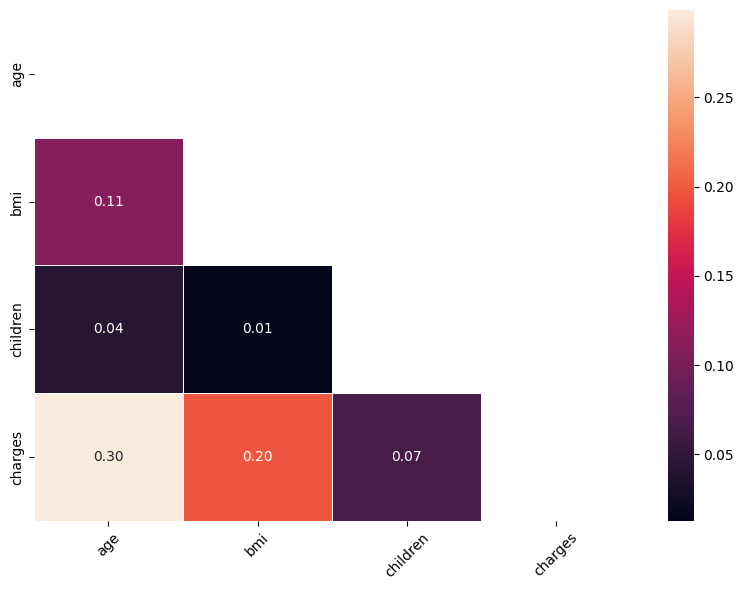

In [7]:
# Numerical features
numerical_columns = ["age", "bmi", "children", "charges"]
corr_numerical_columns = df_factorized[numerical_columns].corr()
mask_numerical = np.triu(np.ones_like(corr_numerical_columns, dtype = bool))

fig, axis = plt.subplots(figsize = (8, 6))
sns.heatmap(corr_numerical_columns, mask = mask_numerical, annot = True, linewidths = 0.5, fmt = ".2f")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

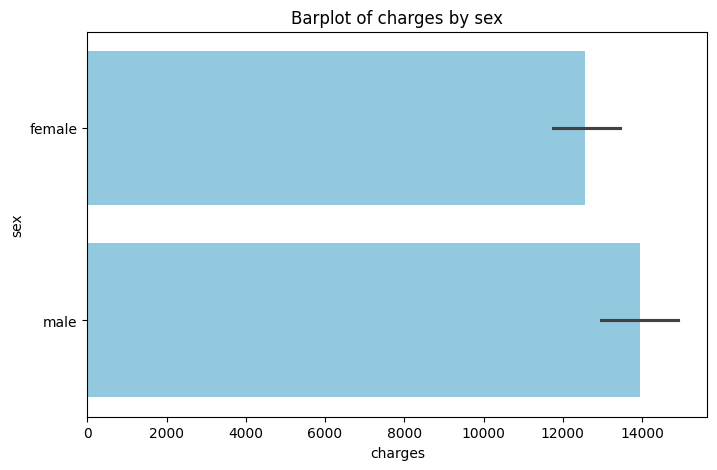

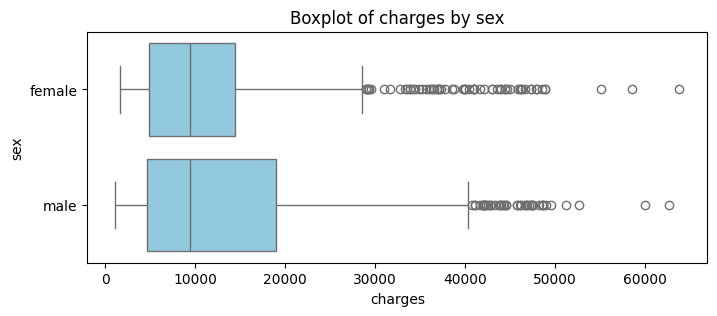

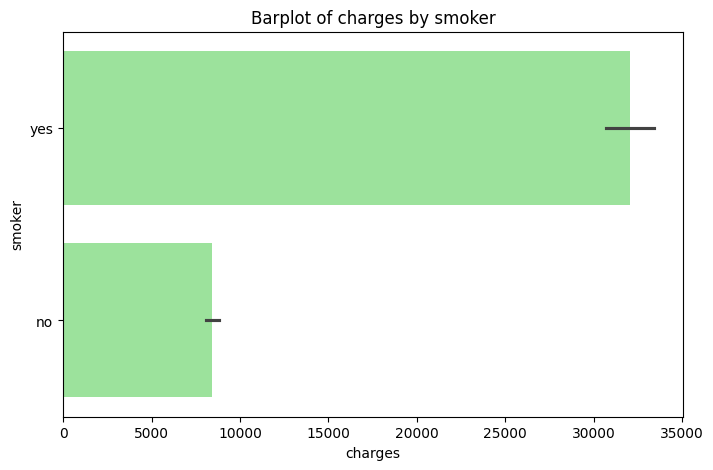

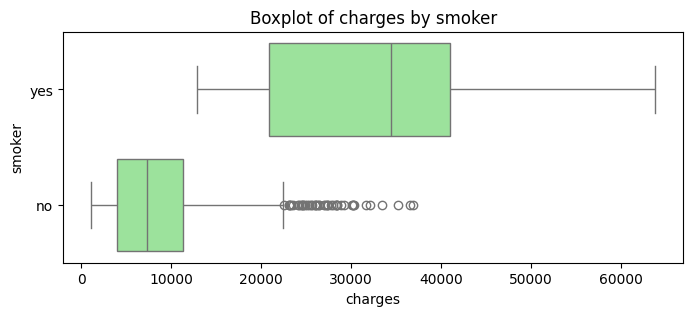

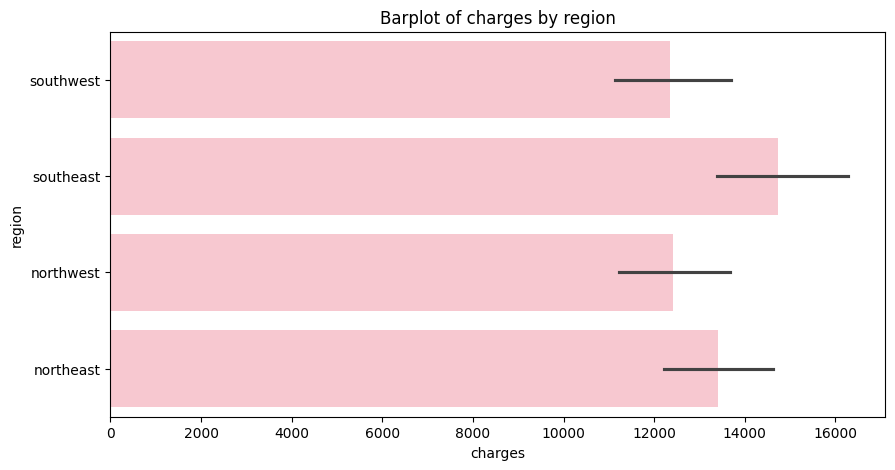

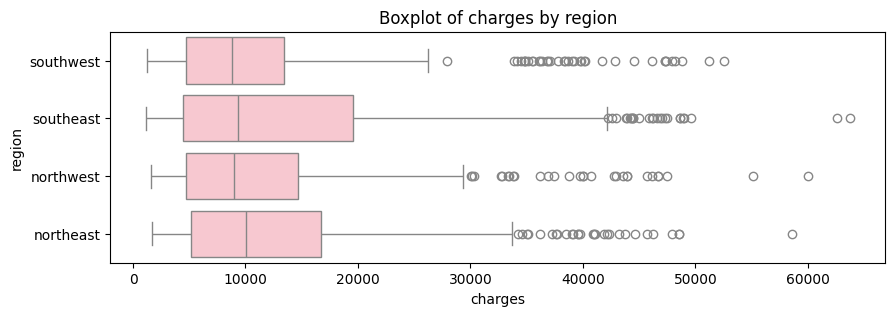

In [8]:
# Categorical features
plt.figure(figsize = (8, 5))
sns.barplot(data = df, y = "sex", x = "charges", color = "skyblue")
plt.title("Barplot of charges by sex")
plt.show()

plt.figure(figsize = (8, 3))
sns.boxplot(data = df, y = "sex", x = "charges", orient = "h", color = "skyblue")
plt.title("Boxplot of charges by sex")
plt.show()

plt.figure(figsize = (8, 5))
sns.barplot(data = df, y = "smoker", x = "charges", color = "lightgreen")
plt.title("Barplot of charges by smoker")
plt.show()

plt.figure(figsize = (8, 3))
sns.boxplot(data = df, y = "smoker", x = "charges", orient = "h", color = "lightgreen")
plt.title("Boxplot of charges by smoker")
plt.show()

plt.figure(figsize = (10, 5))
sns.barplot(data = df, y = "region", x = "charges", color = "pink")
plt.title("Barplot of charges by region")
plt.show()

plt.figure(figsize = (10, 3))
sns.boxplot(data = df, y = "region", x = "charges", orient = "h", color = "pink")
plt.title("Boxplot of charges by region")
plt.show()

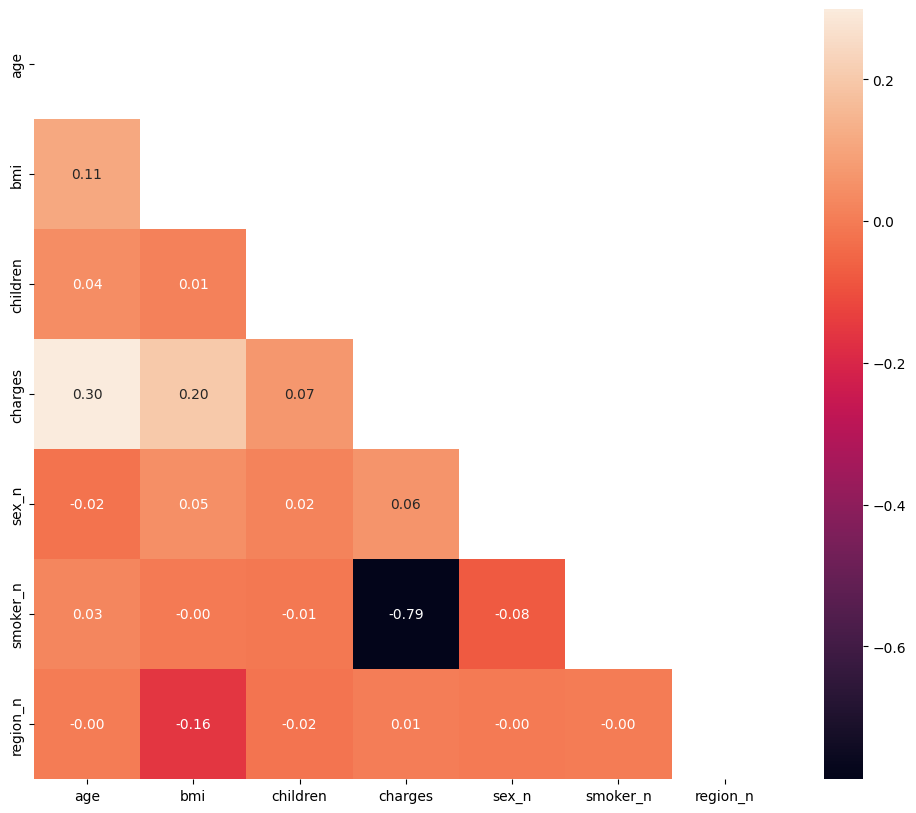

In [9]:
# All features
numeric_df = df_factorized[["age", "bmi", "children", "charges", "sex_n", "smoker_n", "region_n"]]
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

plt.figure(figsize = (12, 10))
sns.heatmap(corr_matrix, mask = mask, annot = True, fmt = ".2f")
plt.show()

In [10]:
# Region appears to not be relevant, so drop it
df.drop(["region"], axis = 1, inplace = True)
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


##### Observations
- In the first plot (numerical features), the strongest correlation is 0.30 between age and charges, but it only indicates a weak relationship.
In the categorical features plots, we observe the following:
- Sex: Males tend to pay slightly more than females, although the difference is minimal. The boxplots also reveal some outliers in both groups.
- Smoker: There is a clear distinction, with smokers paying significantly more than non-smokers. No outliers.
- Region: Charges are fairly uniform across regions, with few outliers. As the plots show, the region does not seem to affect the insurance cost.
- Finally, in the heatmap including all features, the only strong correlation is -0.79 between charges and smoker, which confirms our previous observation.

##### Train/test split

In [11]:
X = df.drop(columns = ["charges"])
y = df["charges"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##### One Hot Encoding

In [12]:
cat_columns = ["sex", "smoker"]
encoder = OneHotEncoder(sparse_output = False)

X_train_encoded = encoder.fit_transform(X_train[cat_columns])
X_test_encoded = encoder.transform(X_test[cat_columns])

X_train_one_hot = pd.DataFrame(X_train_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_train.index)
X_test_one_hot = pd.DataFrame(X_test_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_test.index)

X_train_final = pd.concat([X_train.drop(columns = cat_columns), X_train_one_hot], axis = 1)
X_test_final  = pd.concat([X_test.drop(columns = cat_columns), X_test_one_hot], axis = 1)

In [13]:
X_train_final.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes
560,46,19.95,2,1.0,0.0,1.0,0.0
1285,47,24.32,0,1.0,0.0,1.0,0.0
1142,52,24.86,0,1.0,0.0,1.0,0.0
969,39,34.32,5,1.0,0.0,1.0,0.0
486,54,21.47,3,1.0,0.0,1.0,0.0


##### Feature scaling

In [14]:
# Select only numeric columns + encoded columns
columns_to_scale = ["age", "bmi", "children"] + [column for column in X_train_final.columns if column.startswith("sex_") or column.startswith("smoker_")]

# Standard Scaler
scaler = StandardScaler()
scaler.fit(X_train_final[columns_to_scale])
X_train_scaled = scaler.transform(X_train_final[columns_to_scale])
X_test_scaled  = scaler.transform(X_test_final[columns_to_scale])

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = columns_to_scale, index = X_train_final.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns = columns_to_scale, index = X_test_final.index)

X_train_scaled_df.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes
560,0.472227,-1.756525,0.734336,1.024602,-1.024602,0.508747,-0.508747
1285,0.543313,-1.033082,-0.911192,1.024602,-1.024602,0.508747,-0.508747
1142,0.898745,-0.943687,-0.911192,1.024602,-1.024602,0.508747,-0.508747
969,-0.025379,0.622393,3.202629,1.024602,-1.024602,0.508747,-0.508747
486,1.040918,-1.504893,1.557100,1.024602,-1.024602,0.508747,-0.508747


#### Linear Regression

In [15]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled_df, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# Model's intercept and coefficients
f"Intercept (a): {model.intercept_}, Coefficients (b): {model.coef_}"

'Intercept (a): 13346.089736364485, Coefficients (b): [ 3.61628729e+03  1.97848617e+03  5.19291478e+02  1.98736012e+00\n -1.98736012e+00 -4.77980135e+03  4.77980135e+03]'

In [17]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled_df)
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [18]:
# Evaluating model's performance (Mean Squared Error (MSE) and the Coefficient of Determination (R^2))
f"MSE: {mean_squared_error(y_test, y_pred)}, R^2: {r2_score(y_test, y_pred)}"

'MSE: 33979257.05080822, R^2: 0.7811302113434095'

In [21]:
with open("/workspaces/crerov-intro-machine-learning/models/linear-regression.pkl", "wb") as file:
    pickle.dump(model, file)